## Data Cleaning

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel("../../PCOS_data_without_infertility.xlsx", sheet_name="Full_new")
df.head()

print(data.columns)


## cleaning data, remove junk/id columns 

df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")], errors="ignore")
df = df.drop(columns=["Sl. No", "Patient File No."], errors="ignore")

# clean messy column names (extra spaces)
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)

numeric_cols = [
    "AMH(ng/mL)", "II beta-HCG(mIU/mL)", "I beta-HCG(mIU/mL)",
    "Age (yrs)", "BMI", "Cycle length(days)", "Marraige Status (Yrs)",
    "FSH(mIU/mL)", "LH(mIU/mL)", "FSH/LH",
    "Follicle No. (L)", "Follicle No. (R)"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Decode coded categorical columns
if "Cycle(R/I)" in df.columns:
    df["Cycle(R/I)"] = pd.to_numeric(df["Cycle(R/I)"], errors="coerce").map({2: "Regular", 4: "Irregular"})

blood_map = {11: "A+", 12: "A-", 13: "B+", 14: "B-", 15: "O+", 16: "O-", 17: "AB+", 18: "AB-"}
if "Blood Group" in df.columns:
    df["Blood Group"] = pd.to_numeric(df["Blood Group"], errors="coerce").map(blood_map)

# Drop rows missing the target, impute the rest
df = df.dropna(subset=["PCOS (Y/N)"])
for c in numeric_cols:
    if c in df.columns and df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())
 
df = df.drop_duplicates()
 
print("Cleaned shape:", df.shape)
df.head()
 

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)',
       'Unnamed: 44'],
      dtype='object')
Cleaned shape: (541, 42)


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.300000,O+,78,22,10.48,Regular,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,O+,74,20,11.70,Regular,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.270891,A+,72,18,11.80,Regular,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.674945,B+,72,20,12.00,Regular,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.060954,A+,72,18,10.00,Regular,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


## Line Charts 

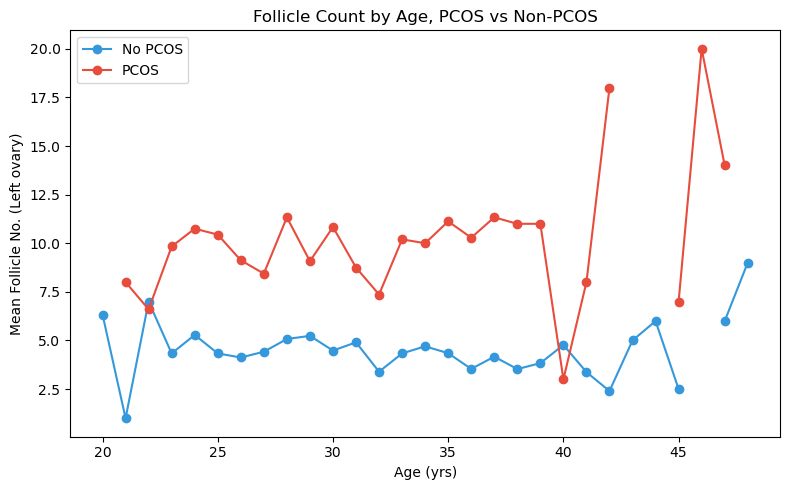

In [16]:
follicle_trend = df.groupby(["Age (yrs)", "PCOS (Y/N)"])["Follicle No. (L)"].mean().unstack()
 
plt.figure(figsize=(8, 5))
plt.plot(follicle_trend.index, follicle_trend[0], marker="o", label="No PCOS", color="#3498db")
plt.plot(follicle_trend.index, follicle_trend[1], marker="o", label="PCOS", color="#e74c3c")
plt.xlabel("Age (yrs)")
plt.ylabel("Mean Follicle No. (Left ovary)")
plt.title("Follicle Count by Age, PCOS vs Non-PCOS")
plt.legend()
plt.tight_layout()
plt.show()

### What this tells us:
Across nearly every age group, PCOS patients have a visibly higher follicle count than non-PCOS patients, matching the clinical diagnostic criteria.

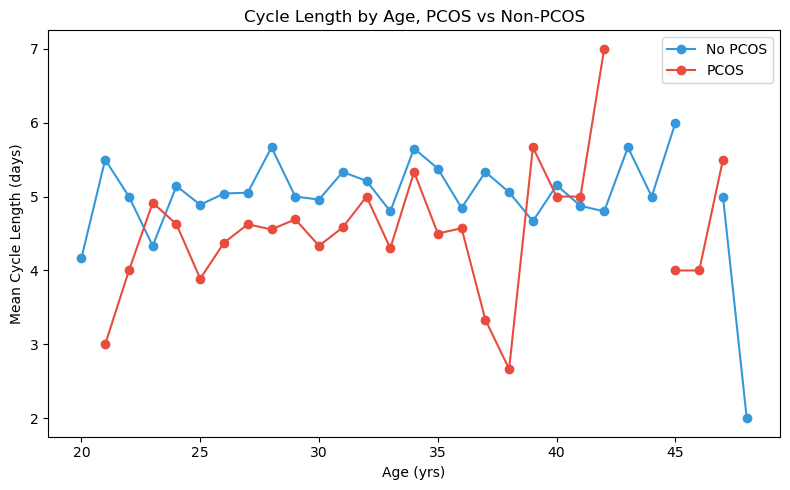

In [17]:
cycle_trend = df.groupby(["Age (yrs)", "PCOS (Y/N)"])["Cycle length(days)"].mean().unstack()
 
plt.figure(figsize=(8, 5))
plt.plot(cycle_trend.index, cycle_trend[0], marker="o", label="No PCOS", color="#3498db")
plt.plot(cycle_trend.index, cycle_trend[1], marker="o", label="PCOS", color="#e74c3c")
plt.xlabel("Age (yrs)")
plt.ylabel("Mean Cycle Length (days)")
plt.title("Cycle Length by Age, PCOS vs Non-PCOS")
plt.legend()
plt.tight_layout()
plt.show()

### What this tells us:
PCOS patients tend to have longer and more variable cycle lengths than non-PCOS patients across most ages, consistent with irregular cycles being a hallmark PCOS symptom.

## Bar Charts 

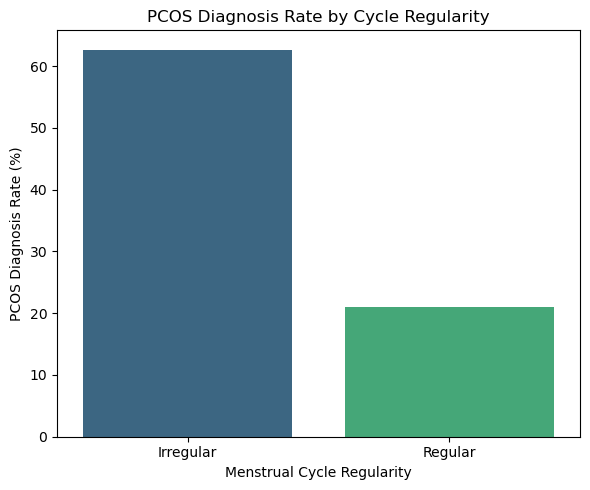

In [19]:
pcos_rate_cycle = df.groupby("Cycle(R/I)")["PCOS (Y/N)"].mean() * 100
 
plt.figure(figsize=(6, 5))
sns.barplot(x=pcos_rate_cycle.index, y=pcos_rate_cycle.values, hue=pcos_rate_cycle.index, palette="viridis", legend=False)
plt.xlabel("Menstrual Cycle Regularity")
plt.ylabel("PCOS Diagnosis Rate (%)")
plt.title("PCOS Diagnosis Rate by Cycle Regularity")
plt.tight_layout()
plt.show()
 

### What this tells us:
Patients with irregular cycles are diagnosed with PCOS at a much higher rate than those with regular cycles, matching cycle irregularity being a core PCOS symptom.
 

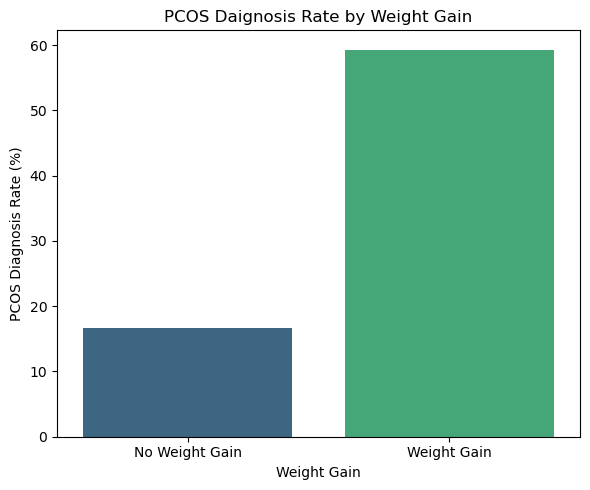

In [20]:
pcos_rate_weight = df.groupby("Weight gain(Y/N)")["PCOS (Y/N)"].mean() * 100
pcos_rate_weight.index = pcos_rate_weight.index.map({0: "No Weight Gain", 1: "Weight Gain"})
 
plt.figure(figsize=(6, 5))
sns.barplot(x=pcos_rate_weight.index, y=pcos_rate_weight.values, hue=pcos_rate_weight.index, palette="viridis", legend=False)
plt.xlabel("Weight Gain")
plt.ylabel("PCOS Diagnosis Rate (%)")
plt.title("PCOS Daignosis Rate by Weight Gain")
plt.tight_layout()
plt.show()
 

### What this tells us:
Patients reporting weight gain are diagnosed with PCOS at a notably higher rate, consistent with weight gain being a common PCOS symptom.

## Histogram

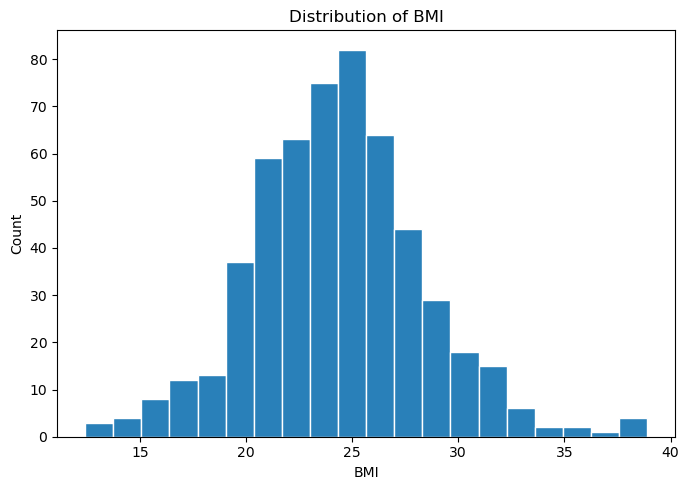

In [21]:
plt.figure(figsize=(7, 5))
plt.hist(df["BMI"], bins=20, color="#2980b9", edgecolor="white")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.title("Distribution of BMI")
plt.tight_layout()
plt.show()
 


### What this tells us:
Most patients cluster in the overweight BMI range, suggesting elevated BMI is common in this sample.

## Boxplot 

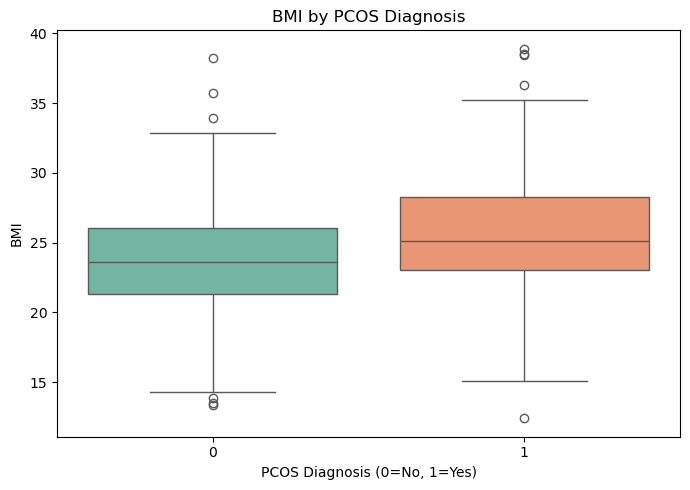

In [25]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="PCOS (Y/N)", y="BMI" , hue="PCOS (Y/N)", palette="Set2", legend=False)
plt.xlabel("PCOS Diagnosis (0=No, 1=Yes)")
plt.ylabel("BMI")
plt.title("BMI by PCOS Diagnosis")
plt.tight_layout()
plt.show()

### What this tells us:
PCOS patients tend to have a higher median BMI than non-PCOS patients, consistent with the known link between obesity and PCOS.

## Scatter Plot

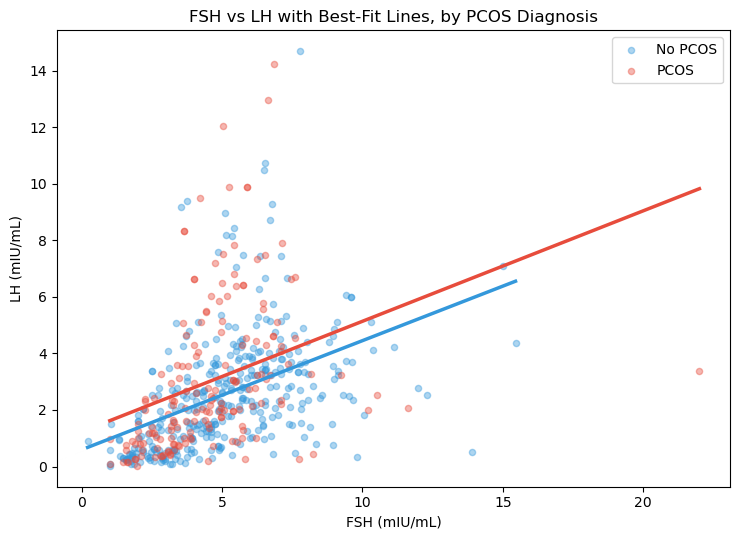

In [31]:
df_horm = df[(df["FSH(mIU/mL)"] < 30) & (df["LH(mIU/mL)"] < 30)]

plt.figure(figsize=(7.5, 5.5))

for diag, color, label in [(0, "#3498db", "No PCOS"), (1, "#e74c3c", "PCOS")]:
    sub = df_horm[df_horm["PCOS (Y/N)"] == diag]
    plt.scatter(sub["FSH(mIU/mL)"], sub["LH(mIU/mL)"], c=color, alpha=0.4, s=20, label=label)

    coeffs = np.polyfit(sub["FSH(mIU/mL)"], sub["LH(mIU/mL)"], deg=1)
    line_x = np.linspace(sub["FSH(mIU/mL)"].min(), sub["FSH(mIU/mL)"].max(), 100)
    line_y = np.polyval(coeffs, line_x)
    plt.plot(line_x, line_y, color=color, linewidth=2.5)

plt.xlabel("FSH (mIU/mL)")
plt.ylabel("LH (mIU/mL)")
plt.title("FSH vs LH with Best-Fit Lines, by PCOS Diagnosis")
plt.legend()
plt.tight_layout()
plt.show()


### What this tells us:
The best-fit lines for both groups have a similar slope and sit close together, confirming that FSH and LH alone don't meaningfully separate PCOS from non-PCOS patients.

## Heatmap

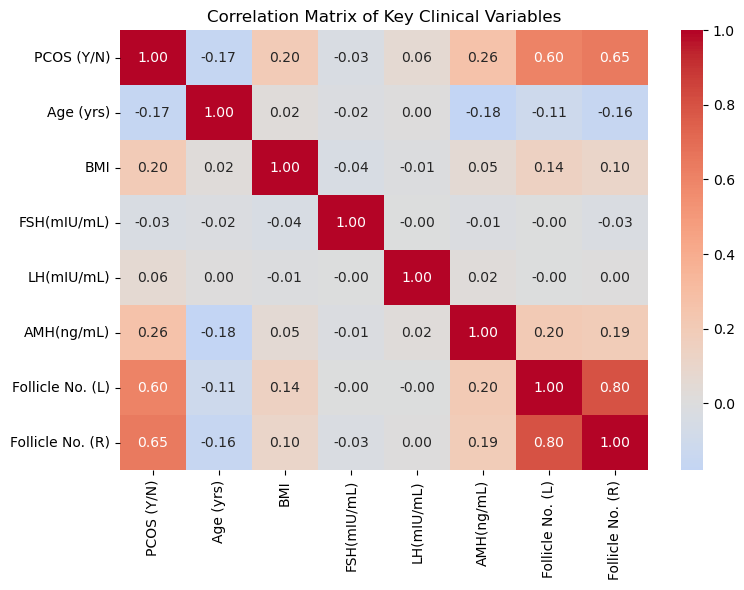

In [30]:
cols_for_corr = ["PCOS (Y/N)", "Age (yrs)", "BMI", "FSH(mIU/mL)", "LH(mIU/mL)",
                  "AMH(ng/mL)", "Follicle No. (L)", "Follicle No. (R)"]
corr = df[cols_for_corr].corr()
 
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Clinical Variables")
plt.tight_layout()
plt.show()
 


### What this tells us:
Follicle counts and AMH show the strongest positive correlation with PCOS diagnosis among these variables.

# THE END